# DBSCAN

In [ ]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [3]:
X,y=make_moons(
    n_samples=500,
    noise=0.1,
    random_state=42
)

In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

<Axes: >

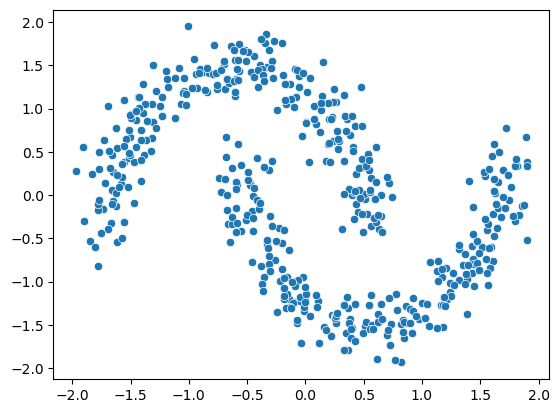

In [5]:
sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1]
)

In [12]:
dbscan=DBSCAN(
    eps=0.18,
    min_samples=5, #feauter * 2 
    
)
labels=dbscan.fit_predict(X_scaled)

<Axes: >

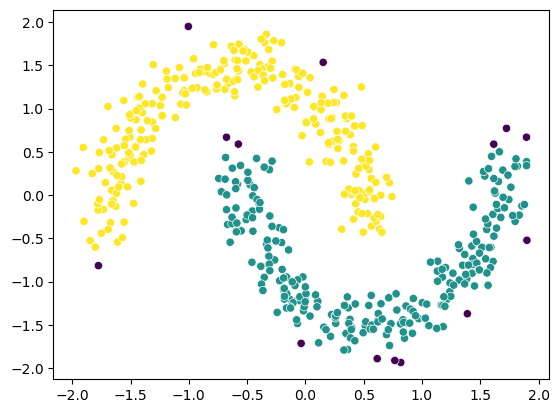

In [13]:
sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    c=labels
)

# Isolation Forest

In [17]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

In [18]:
df=pd.read_csv("data.csv")

In [19]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [20]:
X=df.drop("Outlier_label",axis=1)
y=df["Outlier_label"]

In [22]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [23]:
X_scaled

array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

In [35]:
from sklearn.ensemble import IsolationForest
model=IsolationForest(
    n_estimators=200,
    contamination=0.036,
    random_state=42,
)
labels=model.fit_predict(X_scaled)

In [36]:
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [37]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)


Text(0, 0.5, 'PCA 2')

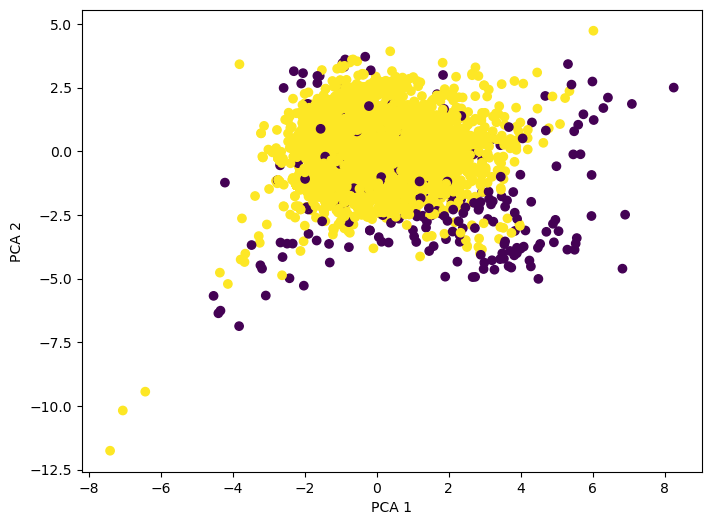

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

In [39]:
import numpy as np
n_outliers=np.sum(labels==-1)
n_normals=np.sum(labels==1)
print("Outliers :" ,n_outliers)
print("Normals :" ,n_normals)

Outliers : 249
Normals : 6667


# LOF -> Local outlier factor

In [43]:
from sklearn.neighbors import LocalOutlierFactor
lof=LocalOutlierFactor(contamination=0.036)
labels=lof.fit_predict(X_scaled)

Text(0, 0.5, 'PCA 2')

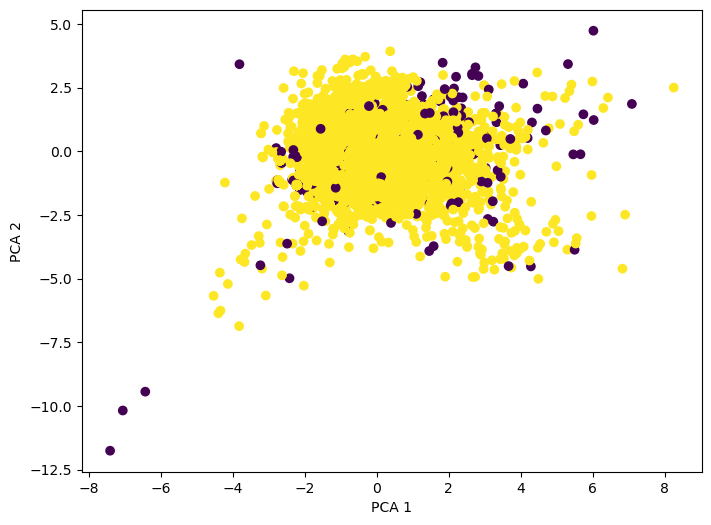

In [44]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

In [45]:
n_outliers=np.sum(labels==-1)
n_normals=np.sum(labels==1)
print("Outliers :" ,n_outliers)
print("Normals :" ,n_normals)

Outliers : 249
Normals : 6667
